# HSI vs RGB Inference Comparison

Compare matched test examples across:
- RGB U-Net
- RGB ViT U-Net
- HSI 3D CNN
- HSI ViT U-Net

All overlays are shown on the RGB patch so the spatial comparison is direct.


In [23]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = PROJECT_ROOT / 'src'

for p in (PROJECT_ROOT, SRC_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from app.inference import load_checkpoint, preprocess_rgb, predict_mask, resize_mask


In [24]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THRESHOLD = 0.5
N_EXAMPLES = 3
OVERLAY_ALPHA = 0.45

RGB_DATA_ROOT = PROJECT_ROOT / 'data' / 'splits' / 'rgb_binary_10pct_balanced'
HSI_DATA_ROOT = PROJECT_ROOT / 'data' / 'splits' / 'hsi_preprocessed_10pct_balanced'
SPLIT = 'val'

MODEL_PATHS = {
    'RGB U-Net': PROJECT_ROOT / 'app' / 'models' / 'rgb_unet' / 'best_model.pth',
    'RGB ViT U-Net': PROJECT_ROOT / 'app' / 'models' / 'rgb_vit' / 'best_model.pth',
    'HSI 3D CNN': PROJECT_ROOT / 'outputs' / 'hsi_3dcnn__nooverlap_run' / 'best_model.pth',
    'HSI ViT U-Net': PROJECT_ROOT / 'outputs' / 'hsi_vit_nooverlap_run_corr' / 'best_model.pth',
}

for name, path in MODEL_PATHS.items():
    print(f'{name}: {path} | exists={path.exists()}')
print('device:', DEVICE)
print('RGB root:', RGB_DATA_ROOT / SPLIT)
print('HSI root:', HSI_DATA_ROOT / SPLIT)


RGB U-Net: /home/echerif/ironhack/neon_tree_crown_v3/app/models/rgb_unet/best_model.pth | exists=True
RGB ViT U-Net: /home/echerif/ironhack/neon_tree_crown_v3/app/models/rgb_vit/best_model.pth | exists=True
HSI 3D CNN: /home/echerif/ironhack/neon_tree_crown_v3/outputs/hsi_3dcnn__nooverlap_run/best_model.pth | exists=True
HSI ViT U-Net: /home/echerif/ironhack/neon_tree_crown_v3/outputs/hsi_vit_nooverlap_run_corr/best_model.pth | exists=True
device: cuda
RGB root: /home/echerif/ironhack/neon_tree_crown_v3/data/splits/rgb_binary_10pct_balanced/val
HSI root: /home/echerif/ironhack/neon_tree_crown_v3/data/splits/hsi_preprocessed_10pct_balanced/val


In [25]:
def overlay_mask(image: np.ndarray, mask: np.ndarray, color=(1.0, 0.2, 0.0), alpha: float = OVERLAY_ALPHA) -> np.ndarray:
    base = image.astype(np.float32)
    if base.max() > 1.0:
        base = base / 255.0
    out = base.copy()
    mask_bool = mask.astype(bool)
    out[mask_bool] = (1 - alpha) * out[mask_bool] + alpha * np.array(color, dtype=np.float32)
    return np.clip(out, 0, 1)


def read_binary_mask(mask_path: Path) -> np.ndarray:
    mask = tifffile.imread(mask_path)
    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    return (mask > 0).astype(np.uint8)


def preprocess_hsi(path: Path) -> tuple[torch.Tensor, np.ndarray]:
    cube = tifffile.imread(path).astype(np.float32)
    if cube.ndim != 3:
        raise ValueError(f'Expected HSI cube with 3 dims, got {cube.shape}')
    # Training uses (B, H, W). Support channels-last if present.
    if cube.shape[0] <= 16 and cube.shape[-1] > 16:
        cube = np.moveaxis(cube, -1, 0)
    raw = cube.copy()
    tensor = torch.from_numpy(cube).unsqueeze(0).float()
    return tensor, raw


def hsi_rgb_vis(cube: np.ndarray) -> np.ndarray:
    if cube.ndim != 3:
        raise ValueError(f'Expected HSI cube with 3 dims, got {cube.shape}')
    if cube.shape[0] <= 16 and cube.shape[-1] > 16:
        cube = np.moveaxis(cube, -1, 0)
    n_bands = cube.shape[0]
    wavelengths = np.linspace(400, 2450, n_bands)
    red = int(np.argmin(np.abs(wavelengths - 650)))
    green = int(np.argmin(np.abs(wavelengths - 550)))
    blue = int(np.argmin(np.abs(wavelengths - 450)))
    rgb = np.stack([cube[red], cube[green], cube[blue]], axis=-1)
    rgb = np.nan_to_num(rgb, nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(rgb, (2, 98))
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)


def infer_rgb_model(model, image_path: Path, device: torch.device, threshold: float, img_size: int | None = None):
    size = img_size or 320
    x, raw = preprocess_rgb(image_path, img_size=size)
    _, pred = predict_mask(model, x, device=device, threshold=threshold)
    pred = resize_mask(pred, raw.shape[:2])
    return raw, pred


def infer_hsi_model(model, cube_path: Path, out_shape_hw: tuple[int, int], device: torch.device, threshold: float):
    x, _ = preprocess_hsi(cube_path)
    _, pred = predict_mask(model, x, device=device, threshold=threshold)
    pred = resize_mask(pred, out_shape_hw)
    return pred


def compute_mask_metrics(pred: np.ndarray, target: np.ndarray) -> dict:
    pred = pred.astype(bool)
    target = target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    pred_sum = pred.sum()
    target_sum = target.sum()
    union = pred_sum + target_sum - inter
    iou = inter / (union + 1e-6)
    dice = (2 * inter) / (pred_sum + target_sum + 1e-6)
    return {'iou': float(iou), 'dice': float(dice), 'f1': float(dice)}



In [26]:
rgb_img_dir = RGB_DATA_ROOT / SPLIT / 'img'
rgb_lbl_dir = RGB_DATA_ROOT / SPLIT / 'labels'
hsi_img_dir = HSI_DATA_ROOT / SPLIT / 'img'
hsi_lbl_dir = HSI_DATA_ROOT / SPLIT / 'labels'

rgb_images = {p.name: p for p in rgb_img_dir.glob('*') if p.suffix.lower() in {'.tif', '.tiff', '.png', '.jpg', '.jpeg'}}
rgb_labels = {p.name: p for p in rgb_lbl_dir.glob('*')}
hsi_images = {p.name: p for p in hsi_img_dir.glob('*.tif')}
hsi_labels = {p.name: p for p in hsi_lbl_dir.glob('*.tif')}

common_names = sorted(set(rgb_images) & set(rgb_labels) & set(hsi_images) & set(hsi_labels))
print('matched examples:', len(common_names))
common_names[:10]


matched examples: 27


['2018_BART_4_322000_4882000_image_crop_patch3.tif',
 '2018_MLBS_3_541000_4140000_image_crop2_patch0.tif',
 '2018_MLBS_3_541000_4140000_image_crop2_patch21.tif',
 '2018_MLBS_3_541000_4140000_image_crop2_patch22.tif',
 '2018_MLBS_3_541000_4140000_image_crop_patch10.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch1.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch14.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch25.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch26.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch29.tif']

In [27]:
models = {}
model_meta = {}
for name, ckpt_path in MODEL_PATHS.items():
    model, _, meta = load_checkpoint(ckpt_path, DEVICE)
    models[name] = model
    model_meta[name] = meta
    print(name, 'loaded | model_type =', meta.get('model_type', 'unknown'))


RGB U-Net loaded | model_type = attn_unet
RGB ViT U-Net loaded | model_type = vit_rgb
HSI 3D CNN loaded | model_type = hsi_3dcnn
HSI ViT U-Net loaded | model_type = vit_hsi


In [31]:
# example_names = common_names[:N_EXAMPLES]
# example_names

example_names = common_names[5:5+N_EXAMPLES]
example_names

['2018_NIWO_2_450000_4426000_image_crop_patch1.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch14.tif',
 '2018_NIWO_2_450000_4426000_image_crop_patch25.tif']

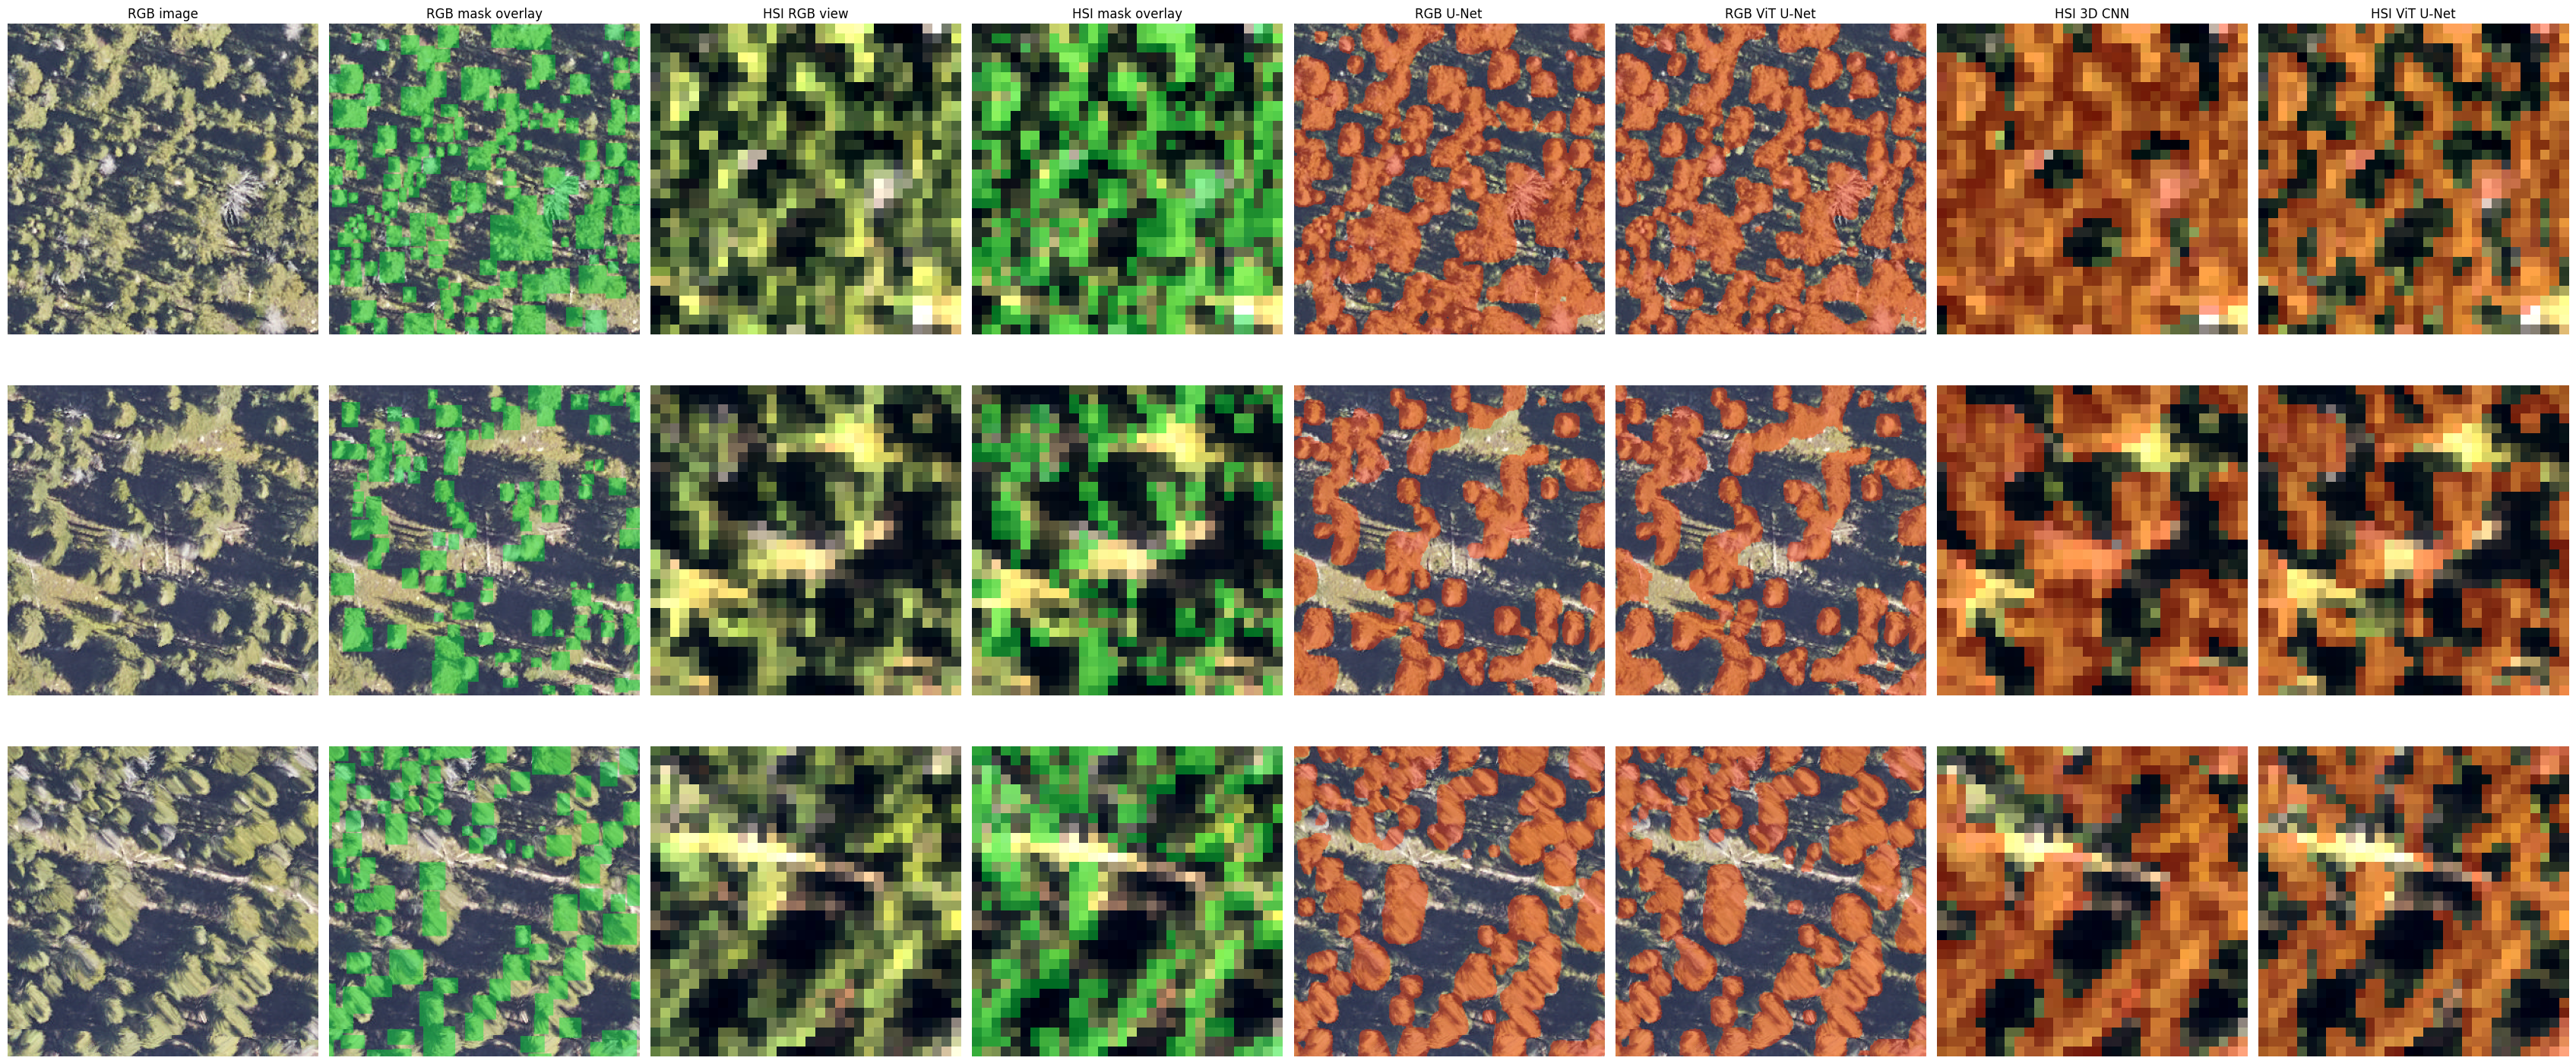

In [32]:
fig, axes = plt.subplots(len(example_names), 8, figsize=(34, 5 * len(example_names)))
if len(example_names) == 1:
    axes = np.array([axes])

col_titles = [
    'RGB image',
    'RGB mask overlay',
    'HSI RGB view',
    'HSI mask overlay',
    'RGB U-Net',
    'RGB ViT U-Net',
    'HSI 3D CNN',
    'HSI ViT U-Net',
]
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title)

for row_idx, name in enumerate(example_names):
    rgb_path = rgb_images[name]
    hsi_path = hsi_images[name]
    rgb_raw = preprocess_rgb(rgb_path, img_size=320)[1]
    hsi_cube = preprocess_hsi(hsi_path)[1]
    hsi_vis = hsi_rgb_vis(hsi_cube)

    rgb_mask = read_binary_mask(rgb_labels[name])
    hsi_mask = read_binary_mask(hsi_labels[name])
    if rgb_mask.shape != rgb_raw.shape[:2]:
        rgb_mask = resize_mask(rgb_mask.astype(np.uint8), rgb_raw.shape[:2])
    if hsi_mask.shape != hsi_vis.shape[:2]:
        hsi_mask = resize_mask(hsi_mask.astype(np.uint8), hsi_vis.shape[:2])

    axes[row_idx, 0].imshow(rgb_raw)
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_ylabel(name, rotation=0, labelpad=110, va='center')

    axes[row_idx, 1].imshow(overlay_mask(rgb_raw, rgb_mask, color=(0.0, 0.9, 0.2), alpha=0.45))
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(hsi_vis)
    axes[row_idx, 2].axis('off')

    axes[row_idx, 3].imshow(overlay_mask(hsi_vis, hsi_mask, color=(0.0, 0.9, 0.2), alpha=0.45))
    axes[row_idx, 3].axis('off')

    rgb_unet_size = int(model_meta['RGB U-Net'].get('img_size', 320)) if isinstance(model_meta['RGB U-Net'], dict) else 320
    rgb_vit_size = int(model_meta['RGB ViT U-Net'].get('img_size', 320)) if isinstance(model_meta['RGB ViT U-Net'], dict) else 320

    _, pred_rgb_unet = infer_rgb_model(models['RGB U-Net'], rgb_path, device=DEVICE, threshold=THRESHOLD, img_size=rgb_unet_size)
    _, pred_rgb_vit = infer_rgb_model(models['RGB ViT U-Net'], rgb_path, device=DEVICE, threshold=THRESHOLD, img_size=rgb_vit_size)
    pred_hsi_3d = infer_hsi_model(models['HSI 3D CNN'], hsi_path, hsi_vis.shape[:2], device=DEVICE, threshold=THRESHOLD)
    pred_hsi_vit = infer_hsi_model(models['HSI ViT U-Net'], hsi_path, hsi_vis.shape[:2], device=DEVICE, threshold=THRESHOLD)

    axes[row_idx, 4].imshow(overlay_mask(rgb_raw, pred_rgb_unet))
    axes[row_idx, 4].axis('off')
    axes[row_idx, 5].imshow(overlay_mask(rgb_raw, pred_rgb_vit))
    axes[row_idx, 5].axis('off')
    axes[row_idx, 6].imshow(overlay_mask(hsi_vis, pred_hsi_3d))
    axes[row_idx, 6].axis('off')
    axes[row_idx, 7].imshow(overlay_mask(hsi_vis, pred_hsi_vit))
    axes[row_idx, 7].axis('off')

plt.tight_layout()

## Test-set metrics across RGB and HSI models

Compute IoU / Dice / F1 on the matched test set where both RGB and HSI examples exist.


In [13]:
results = []
for model_name in ['RGB U-Net', 'RGB ViT U-Net', 'HSI 3D CNN', 'HSI ViT U-Net']:
    metric_rows = []
    for name in common_names:
        rgb_path = rgb_images[name]
        hsi_path = hsi_images[name]
        target = read_binary_mask(rgb_labels[name])
        rgb_raw = preprocess_rgb(rgb_path, img_size=320)[1]
        if target.shape != rgb_raw.shape[:2]:
            target = resize_mask(target.astype(np.uint8), rgb_raw.shape[:2])

        if model_name.startswith('RGB'):
            img_size = int(model_meta[model_name].get('img_size', 320)) if isinstance(model_meta[model_name], dict) else 320
            _, pred = infer_rgb_model(models[model_name], rgb_path, device=DEVICE, threshold=THRESHOLD, img_size=img_size)
        else:
            pred = infer_hsi_model(models[model_name], hsi_path, rgb_raw.shape[:2], device=DEVICE, threshold=THRESHOLD)

        metric_rows.append(compute_mask_metrics(pred, target))

    results.append({
        'model': model_name,
        'iou': float(np.mean([m['iou'] for m in metric_rows])),
        'dice': float(np.mean([m['dice'] for m in metric_rows])),
        # 'f1': float(np.mean([m['f1'] for m in metric_rows])),
        'n_test': len(metric_rows),
    })

results_df = pd.DataFrame(results)
results_df


,model,iou,dice,n_test
0,RGB U-Net,0.614009,0.740679,27
1,RGB ViT U-Net,0.619288,0.746514,27
2,HSI 3D CNN,0.347793,0.460619,27
3,HSI ViT U-Net,0.374047,0.479553,27


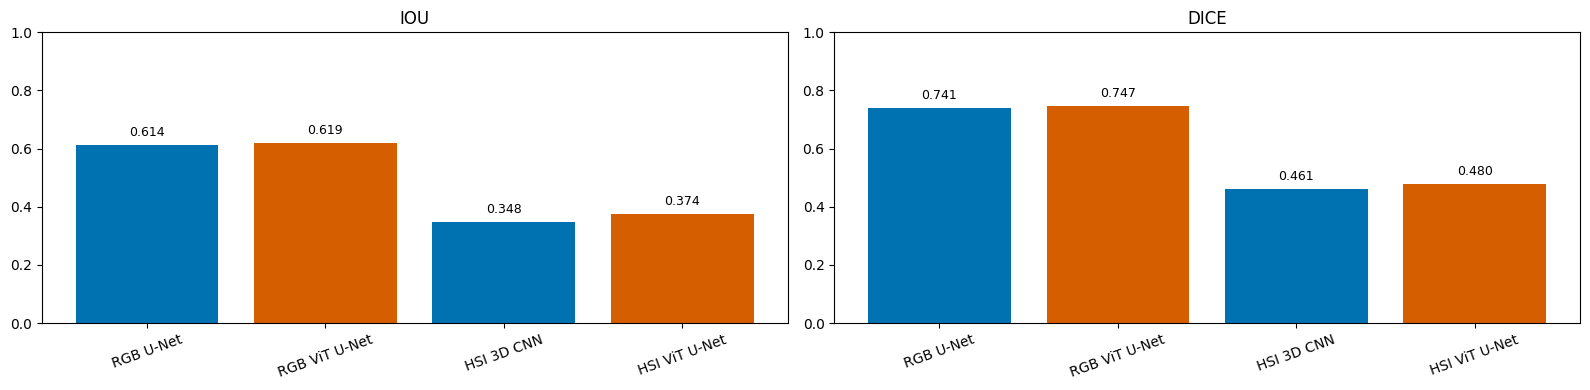

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
# metric_names = ['iou', 'dice', 'f1']
metric_names = ['iou', 'dice']
colors = ['#0072B2', "#D55E00", '#0072B2', '#D55E00']

for ax, metric in zip(axes, metric_names):
    ax.bar(results_df['model'], results_df[metric], color=colors[:len(results_df)])
    ax.set_title(metric.upper())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    for idx, value in enumerate(results_df[metric]):
        ax.text(idx, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()


Notes:
- This notebook assumes RGB and HSI test examples share the same filename.
- HSI predictions are resized to the RGB patch size for visualization and metric comparison.
- Update `MODEL_PATHS` if you want to compare different checkpoints.


Text(0.01, 0.99, '\nTREE CROWN SEGMENTATION METRICS\n\n1) Tree Cover (Canopy Cover)\n   C = (N_tree_pixels / N_total_pixels) × 100\n\n2) Tree Count\n   T = number of detected crown objects\n\n3) Crown Area (per tree)\n   A_i = n_i × (GSD)^2\n\n4) Average Crown Area\n   Ā = (1/T) × Σ A_i\n\n5) Crown Area Variance\n   σ² = (1/T) × Σ (A_i − Ā)²\n\n6) Tree Density\n   D = T / A\n   D_ha = (T / A) × 10,000\n\n7) Mean Nearest Neighbor Distance\n   d̄ = (1/T) × Σ d_i\n\n8) Nearest Neighbor Index (Clark–Evans)\n   R = d_observed / d_expected\n   d_expected = 1 / (2√ρ)\n\n9) Fragmentation Index\n   F = P / A_c\n\n10) Canopy Area\n   A_c = N_tree_pixels × (GSD)^2\n')

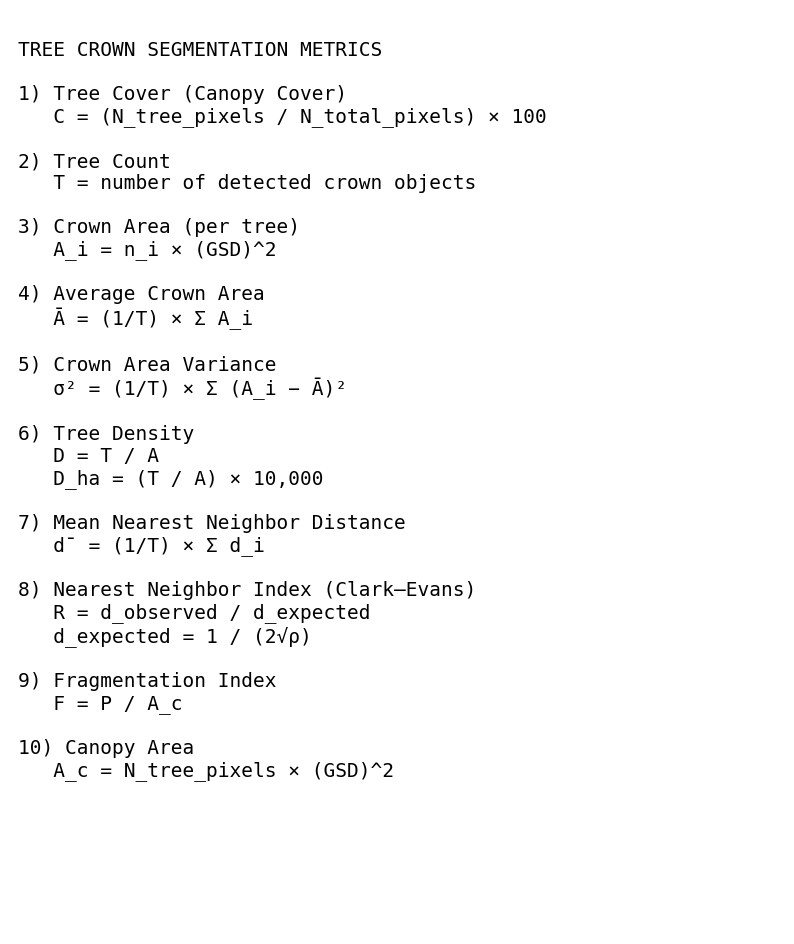

In [21]:
# Create a PNG "infographic" listing the tree crown metrics with their formulas
import matplotlib.pyplot as plt

text = """
TREE CROWN SEGMENTATION METRICS

1) Tree Cover (Canopy Cover)
   C = (N_tree_pixels / N_total_pixels) × 100

2) Tree Count
   T = number of detected crown objects

3) Crown Area (per tree)
   A_i = n_i × (GSD)^2

4) Average Crown Area
   Ā = (1/T) × Σ A_i

5) Crown Area Variance
   σ² = (1/T) × Σ (A_i − Ā)²

6) Tree Density
   D = T / A
   D_ha = (T / A) × 10,000

7) Mean Nearest Neighbor Distance
   d̄ = (1/T) × Σ d_i

8) Nearest Neighbor Index (Clark–Evans)
   R = d_observed / d_expected
   d_expected = 1 / (2√ρ)

9) Fragmentation Index
   F = P / A_c

10) Canopy Area
   A_c = N_tree_pixels × (GSD)^2
"""

fig = plt.figure(figsize=(10, 12))
plt.axis("off")
plt.text(0.01, 0.99, text, va="top", ha="left", fontsize=14, family="monospace")

# output_path = "/mnt/data/tree_crown_metrics.png"
# plt.savefig(output_path, bbox_inches="tight", dpi=300)
# plt.close()

# output_path

Text(0.01, 0.99, '\nECOLOGICAL SIGNIFICANCE OF TREE CROWN METRICS\n\n1) Tree Cover (%)\n   Interpretation:\n   - Indicates proportion of ground covered by tree canopy.\n   - Proxy for vegetation productivity, shading, and habitat availability.\n\n2) Tree Count\n   Interpretation:\n   - Estimates number of individual trees in the scene.\n   - Useful for understanding stand density and forest structure.\n\n3) Average Crown Area\n   Interpretation:\n   - Larger crowns often correspond to mature or dominant trees.\n   - Smaller crowns may indicate younger vegetation or competition.\n\n4) Crown Area Variance\n   Interpretation:\n   - High variance → heterogeneous forest with multiple tree sizes.\n   - Low variance → uniform structure, often plantations.\n\n5) Tree Density (trees per hectare)\n   Interpretation:\n   - Low density → open woodland or scattered vegetation.\n   - High density → dense forest or plantation.\n\n6) Mean Nearest Neighbor Distance\n   Interpretation:\n   - Describes s

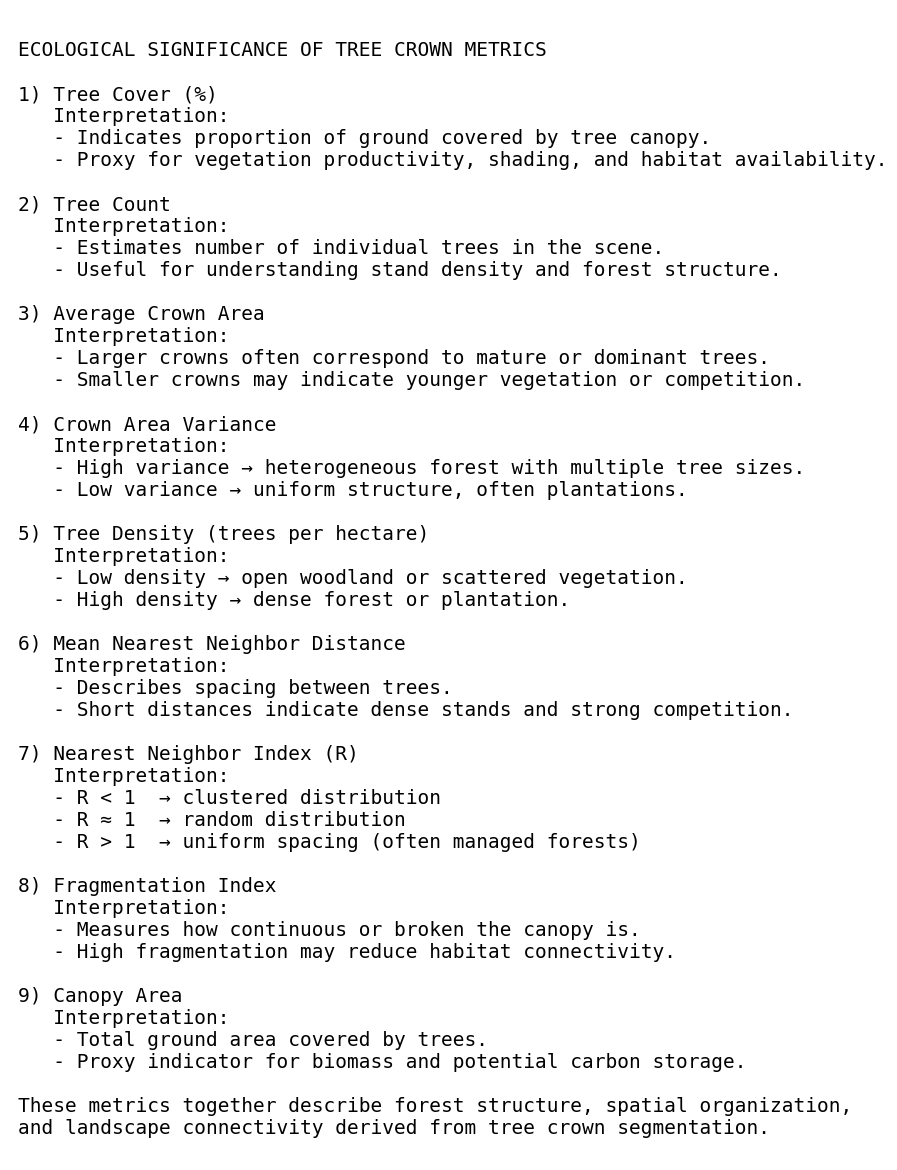

In [22]:
# Generate a PNG infographic explaining the significance and interpretation of the tree crown metrics
import matplotlib.pyplot as plt

text = """
ECOLOGICAL SIGNIFICANCE OF TREE CROWN METRICS

1) Tree Cover (%)
   Interpretation:
   - Indicates proportion of ground covered by tree canopy.
   - Proxy for vegetation productivity, shading, and habitat availability.

2) Tree Count
   Interpretation:
   - Estimates number of individual trees in the scene.
   - Useful for understanding stand density and forest structure.

3) Average Crown Area
   Interpretation:
   - Larger crowns often correspond to mature or dominant trees.
   - Smaller crowns may indicate younger vegetation or competition.

4) Crown Area Variance
   Interpretation:
   - High variance → heterogeneous forest with multiple tree sizes.
   - Low variance → uniform structure, often plantations.

5) Tree Density (trees per hectare)
   Interpretation:
   - Low density → open woodland or scattered vegetation.
   - High density → dense forest or plantation.

6) Mean Nearest Neighbor Distance
   Interpretation:
   - Describes spacing between trees.
   - Short distances indicate dense stands and strong competition.

7) Nearest Neighbor Index (R)
   Interpretation:
   - R < 1  → clustered distribution
   - R ≈ 1  → random distribution
   - R > 1  → uniform spacing (often managed forests)

8) Fragmentation Index
   Interpretation:
   - Measures how continuous or broken the canopy is.
   - High fragmentation may reduce habitat connectivity.

9) Canopy Area
   Interpretation:
   - Total ground area covered by trees.
   - Proxy indicator for biomass and potential carbon storage.

These metrics together describe forest structure, spatial organization,
and landscape connectivity derived from tree crown segmentation.
"""

fig = plt.figure(figsize=(10, 12))
plt.axis("off")
plt.text(0.01, 0.99, text, va="top", ha="left", fontsize=14, family="monospace")

# output_path = "/mnt/data/tree_crown_metrics_significance.png"
# plt.savefig(output_path, bbox_inches="tight", dpi=300)
# plt.close()

# output_path